# Caderno 8 - Comparação de ranking de sistemas de busca gerado por diversos qrels

## 1. Parâmetros

In [1]:
PASTA_DOCS_QRELS = './dados/outputs/0 - qrel - docs - query - raw_human_eval/'
PASTA_QRELS_LEAVE_ONE_OUT = f'{PASTA_DOCS_QRELS}qrels possiveis/'
PASTA_QRELS_LLMS = './dados/outputs/4 - qrel llm/'
PASTA_RUNS = './dados/outputs/7 - runs/'

ARQUIVO_QRELS = f'{PASTA_DOCS_QRELS}qrel.csv'
ARQUIVO_RAW_HUMAN_EVAL = f'{PASTA_DOCS_QRELS}raw_human_eval.csv'

In [2]:
MAPA_NOME_RUNS = {
    'run_bm25_0.9_0.4_assunto_e_texto': 'S_1',
    'run_bm25_0.9_0.4_texto': 'S_2',
    'run_bm25_0.82_0.68_assunto_e_texto': 'S_3',
    'run_bm25_0.82_0.68_texto': 'S_4',
    'run_bm25_1_0.3_assunto_e_texto': 'S_5',
    'run_bm25_1_0.3_texto': 'S_6',
    'run_bm25_1_0.9_assunto_e_texto': 'S_7',
    'run_bm25_1_0.9_texto': 'S_8',
    'run_text-embedding-3-large': 'S_9',
    'run_text-embedding-3-small': 'S_10',
    'run_gemini-embedding-001': 'S_11',
    'run_qwen_4b': 'S_12',
    'run_qwen_8b': 'S_13',
    'run_bm25_1_0.9_texto_text-embedding-3-small': 'S_14',
    'run_bm25_1_0.9_texto_gemini-embedding-001': 'S_15'
}

MAPA_NOME_QRELS = {
    'qrel_deepseek-chat_cot': 'deepseek_cot',
    'qrel_deepseek-chat_simple': 'deepseek_simple',
    'qrel_gpt-5-mini-2025-08-07_cot': 'gpt-5-mini_cot',
    'qrel_gpt-5-mini-2025-08-07_simple': 'gpt-5-mini_simple',
    'qrel_sabiazinho-4-2026-01-06_cot': 'sabiazinho-4_cot',
    'qrel_sabiazinho-4-2026-01-06_simple': 'sabiazinho-4_simple'
}

# Guarda a ordem para exibição dos gráficos
NOME_QRELS_REF = "Reference"
CARREGAR_QRELS_LEAVE_ONE_OUT = False
subtitle_order = [
    NOME_QRELS_REF,
    # Para o caso de querer testar com os leave_one_out, descomentar as linhas abaixo e setar CARREGAR_QRELS_LEAVE_ONE_OUT = True
    #"qrels_leave_A_1_out",
    #"qrels_leave_A_2_out",
    #"qrels_leave_A_3_out",
    #"qrels_leave_A_4_out",
    "A_1",
    "A_2",
    "A_3",
    "A_4",
    "deepseek_simple",
    "gpt-5-mini_simple",
    "sabiazinho-4_simple",
    "deepseek_cot",
    "gpt-5-mini_cot",
    "sabiazinho-4_cot",
]

## 2. Carrega todos os qrels

In [3]:
# Carrega todos os qrels de LLMs
from pathlib import Path
import pandas as pd

qrels = {}

# Carrega o qrels humano
qrels[NOME_QRELS_REF] = pd.read_csv(ARQUIVO_QRELS)

# Carrega os qrels leave-one-out
if CARREGAR_QRELS_LEAVE_ONE_OUT:
    qrels["qrels_leave_A_1_out"] = pd.read_csv(f'{PASTA_QRELS_LEAVE_ONE_OUT}qrels_leave_A_1_out.csv')
    qrels["qrels_leave_A_2_out"] = pd.read_csv(f'{PASTA_QRELS_LEAVE_ONE_OUT}qrels_leave_A_2_out.csv')
    qrels["qrels_leave_A_3_out"] = pd.read_csv(f'{PASTA_QRELS_LEAVE_ONE_OUT}qrels_leave_A_3_out.csv')
    qrels["qrels_leave_A_4_out"] = pd.read_csv(f'{PASTA_QRELS_LEAVE_ONE_OUT}qrels_leave_A_4_out.csv')

########## CARREGA QRELS LLM ########## 

# Percorre todos os arquivos .csv da pasta
PASTA_QRELS_LLMS = Path(PASTA_QRELS_LLMS)
for arquivo in PASTA_QRELS_LLMS.glob("*.csv"):
    # Nome do arquivo sem extensão
    nome_qrels = arquivo.stem
    
    # Lê o CSV
    df = pd.read_csv(arquivo)
    
    # Salva no dicionário
    qrels[MAPA_NOME_QRELS.get(nome_qrels, nome_qrels)] = df


########## CARREGA QRELS ANOTADORES HUMANOS INDIVIDUAIS ########## 

# Gera os qrels de cada anotador individual
df_raw_human_eval = pd.read_csv(ARQUIVO_RAW_HUMAN_EVAL)
# Renomeia SCORE
df_raw_human_eval = df_raw_human_eval.rename(columns={"AVALIACAO": "SCORE"})
# Agrupa por usuário/query_key/score
df_raw_human_eval = df_raw_human_eval.sort_values(
    by=["USUARIO_AVALIADOR", "QUERY_KEY", "SCORE"],
    ascending=[True, True, False]
)
# Cria RANK (reinicia para cada QUERY_KEY dentro de cada avaliador)
df_raw_human_eval["RANK"] = (
    df_raw_human_eval.groupby(["USUARIO_AVALIADOR", "QUERY_KEY"])
      .cumcount() + 1
)
# Cria um df para cada avaliador
for user, grupo in df_raw_human_eval.groupby("USUARIO_AVALIADOR"):
    qrels[user] = grupo[["QUERY_KEY", "DOC_KEY", "SCORE", "RANK"]].reset_index(drop=True)

print(f"{len(qrels)} arquivos carregados.")

11 arquivos carregados.


## 3. Carrega todos os runs

In [4]:
runs = {}

# Percorre todos os arquivos .csv da pasta
PASTA_RUNS = Path(PASTA_RUNS)
for arquivo in PASTA_RUNS.glob("*.csv"):
    # Nome do arquivo sem extensão
    nome_run = arquivo.stem
    
    # Lê o CSV
    df = pd.read_csv(arquivo)
    
    # Salva no dicionário
    runs[MAPA_NOME_RUNS[nome_run]] = df

print(f"{len(runs)} arquivos carregados.")

15 arquivos carregados.


In [5]:
# Exporta todos os runs em um único df, caso seja necessário.
import pandas as pd

dfs = []

for modelo, df in runs.items():
    df_copy = df.copy()
    df_copy["MODELO"] = modelo
    dfs.append(df_copy)

# Concatena tudo
df_final = pd.concat(dfs, ignore_index=True)

# Opcional: colocar MODELO como primeira coluna
cols = ["MODELO"] + [c for c in df_final.columns if c != "MODELO"]
df_final = df_final[cols]

# Salva
#df_final.to_csv("df_todos_runs.csv", index=False)

#print("CSV gerado com sucesso.")

## 4. Gera métricas para todos os runs usando todos os pares de qrels

In [6]:
from metricas import metricas

results = []

for qrels_name, df_qrels in qrels.items():
    for run_name, df_run in runs.items():
        
        # Aqui você calcula as métricas
        df_resultados = metricas(df_run, df_qrels, k=[10])

        metricas_disponiveis = ['P@10', 'R@10', 'nDCG@10', 'MRR']
        for metrica_name in metricas_disponiveis:
            results.append({
                "qrels": qrels_name,
                "run": run_name,
                "metric": metrica_name,
                "value": df_resultados[metrica_name].mean(),
                "std": df_resultados[metrica_name].std()
            })

df_metricas = pd.DataFrame(results)

Ordena os sistemas por métrica:

In [7]:
x = df_metricas[df_metricas.qrels==NOME_QRELS_REF]
x = x[x.metric == 'nDCG@10'].sort_values('value', ascending=False)
x

,qrels,run,metric,value,std
18,Reference,S_5,nDCG@10,0.388022,0.307520
10,Reference,S_1,nDCG@10,0.373450,0.308934
22,Reference,S_6,nDCG@10,0.355897,0.304513
2,Reference,S_3,nDCG@10,0.349561,0.317540
14,Reference,S_2,nDCG@10,0.344428,0.299930
26,Reference,S_7,nDCG@10,0.334672,0.313275
6,Reference,S_4,nDCG@10,0.316056,0.296451
34,Reference,S_15,nDCG@10,0.310239,0.294020
46,Reference,S_12,nDCG@10,0.307034,0.284319
38,Reference,S_14,nDCG@10,0.297224,0.309456


Para calcular as mudanças de posição dos sistemas para determinada métrica

In [8]:
# filtra só a métrica desejada
df = df_metricas[df_metricas.metric == 'nDCG@10'].copy()

# calcula rank dentro de cada qrels
df['rank'] = df.groupby('qrels')['value'].rank(ascending=False, method='min')

# cria tabela runs x qrels
table = df.pivot(index='run', columns='qrels', values='rank')

# garante ordem das colunas
table = table[subtitle_order]

# ordena linhas pelo qrels de referência
table = table.sort_values(NOME_QRELS_REF)

table

qrels,Reference,A_1,A_2,A_3,A_4,deepseek_simple,gpt-5-mini_simple,sabiazinho-4_simple,deepseek_cot,gpt-5-mini_cot,sabiazinho-4_cot
run,,,,,,,,,,,
S_5,1.0,1.0,3.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0
S_1,2.0,2.0,2.0,2.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0
S_6,3.0,3.0,9.0,3.0,8.0,4.0,3.0,4.0,4.0,4.0,4.0
S_3,4.0,4.0,4.0,5.0,5.0,3.0,4.0,3.0,3.0,3.0,3.0
S_2,5.0,5.0,8.0,4.0,9.0,6.0,5.0,5.0,5.0,5.0,5.0
S_7,6.0,6.0,5.0,6.0,7.0,5.0,6.0,6.0,6.0,6.0,6.0
S_4,7.0,7.0,10.0,7.0,11.0,8.0,7.0,7.0,7.0,7.0,7.0
S_15,8.0,8.0,6.0,10.0,4.0,9.0,10.0,10.0,9.0,10.0,9.0
S_12,9.0,11.0,1.0,9.0,1.0,7.0,8.0,9.0,8.0,8.0,8.0


Mostar quantas mudanças de posição tiveram em relação à referência (conta cada linha diferente como uma mudança de posição => Um único swap vai dar duas mudanças de posição)

In [9]:
ref = table[NOME_QRELS_REF]

mudancas = (table.sub(ref, axis=0) != 0).sum()
mudancas = mudancas.drop(NOME_QRELS_REF)

mudancas

qrels
A_1                     5
A_2                    12
A_3                     4
A_4                    14
deepseek_simple        12
gpt-5-mini_simple       6
sabiazinho-4_simple     8
deepseek_cot            8
gpt-5-mini_cot          8
sabiazinho-4_cot        8
dtype: int64

## 5. Calcula a correlação do ranking dos sistemas usando Kendall Tau e coeficiente de Spearman

In [10]:
from scipy.stats import kendalltau, spearmanr
import pandas as pd

resultados_correlacao = []

metricas_disponiveis = df_metricas["metric"].unique()

for metrica in metricas_disponiveis:
    # Filtra apenas essa métrica
    df_metrica = df_metricas[df_metricas["metric"] == metrica]
    
    # Pivot: linhas = runs, colunas = qrels
    pivot = df_metrica.pivot(
        index="run",
        columns="qrels",
        values="value"
    )
       
    # Ranking induzido pelo qrels humano
    valores_human = pivot[NOME_QRELS_REF]
    
    for qrels_name in pivot.columns:
        if qrels_name == NOME_QRELS_REF:
            continue
        
        valores_outro = pivot[qrels_name]
        
        # Calcula Kendall tau-b
        tau, p_tau = kendalltau(valores_human, valores_outro)
        
        # Calcula Spearman rho
        rho, p_rho = spearmanr(valores_human, valores_outro)
        
        resultados_correlacao.append({
            "metric": metrica,
            "qrels_comparado": qrels_name,
            "kendall_tau": tau,
            "kendall_pvalue": p_tau,
            "spearman_rho": rho,
            "spearman_pvalue": p_rho
        })

df_correlacoes = pd.DataFrame(resultados_correlacao)

# Ordena pelo nome do qrels
df_correlacoes['qrels_comparado'] = pd.Categorical(
    df_correlacoes['qrels_comparado'],
    categories=subtitle_order,
    ordered=True
)
df_correlacoes = df_correlacoes.sort_values('qrels_comparado')


#df_correlacoes.sort_values(["metric", "kendall_tau"], ascending=[True, False], inplace=True)

df_correlacoes.reset_index(drop=True, inplace=True)

df_correlacoes

,metric,qrels_comparado,kendall_tau,kendall_pvalue,spearman_rho,spearman_pvalue
0,P@10,A_1,0.864118,9.602608e-06,0.953407,3.879288e-08
1,nDCG@10,A_1,0.942857,1.015543e-09,0.985714,1.929095e-11
2,MRR,A_1,0.923810,4.472061e-09,0.982143,8.157334e-11
3,R@10,A_1,0.923810,4.472061e-09,0.982143,8.157334e-11
4,P@10,A_2,0.643910,1.015840e-03,0.808072,2.673774e-04
5,nDCG@10,A_2,0.542857,4.142882e-03,0.696429,3.921191e-03
6,MRR,A_2,0.790476,4.906475e-06,0.928571,5.867938e-07
7,R@10,A_2,0.161905,4.351189e-01,0.207143,4.588428e-01
8,nDCG@10,A_3,0.923810,4.472061e-09,0.982143,8.157334e-11
9,R@10,A_3,0.885714,5.337720e-08,0.967857,3.596536e-09


In [11]:
metricas_desejadas = ["P@10", "R@10", "nDCG@10", "MRR"]

# Filtra apenas as métricas desejadas
df_filtrado = df_correlacoes[
    df_correlacoes["metric"].isin(metricas_desejadas)
].copy()

# Garante a ordem correta
df_filtrado["metric"] = pd.Categorical(
    df_filtrado["metric"],
    categories=metricas_desejadas,
    ordered=True
)

df_filtrado = df_filtrado.sort_values("metric")

# Impressão organizada
for metrica in metricas_desejadas:
    df_metrica = df_filtrado[df_filtrado["metric"] == metrica]
    
    print(f"\n=== {metrica} ===")
    
    for _, row in df_metrica.iterrows():
        print(
            f"{row['qrels_comparado']}: "
            f"Kendall = {row['kendall_tau']:.4f} | "
            f"Spearman = {row['spearman_rho']:.4f}"
        )


=== P@10 ===
A_1: Kendall = 0.8641 | Spearman = 0.9534
gpt-5-mini_cot: Kendall = 0.8117 | Spearman = 0.9329
deepseek_cot: Kendall = 0.8195 | Spearman = 0.9489
sabiazinho-4_simple: Kendall = 0.7670 | Spearman = 0.9077
gpt-5-mini_simple: Kendall = 0.7864 | Spearman = 0.9220
deepseek_simple: Kendall = 0.8317 | Spearman = 0.9361
A_4: Kendall = 0.8447 | Spearman = 0.9516
A_3: Kendall = 0.8253 | Spearman = 0.9462
sabiazinho-4_cot: Kendall = 0.8253 | Spearman = 0.9373
A_2: Kendall = 0.6439 | Spearman = 0.8081

=== R@10 ===
A_3: Kendall = 0.8857 | Spearman = 0.9679
A_2: Kendall = 0.1619 | Spearman = 0.2071
gpt-5-mini_cot: Kendall = 0.8095 | Spearman = 0.9286
A_4: Kendall = 0.2762 | Spearman = 0.4107
deepseek_simple: Kendall = 0.8095 | Spearman = 0.9429
deepseek_cot: Kendall = 0.8476 | Spearman = 0.9571
sabiazinho-4_cot: Kendall = 0.8476 | Spearman = 0.9571
gpt-5-mini_simple: Kendall = 0.7905 | Spearman = 0.9321
A_1: Kendall = 0.9238 | Spearman = 0.9821
sabiazinho-4_simple: Kendall = 0.7714 | 

In [12]:
metricas_desejadas = ["P@10", "R@10", "nDCG@10", "MRR"]

# Filtra métricas desejadas
df_filtrado = df_correlacoes[
    df_correlacoes["metric"].isin(metricas_desejadas)
].copy()

# Garante a ordem correta das métricas
df_filtrado["metric"] = pd.Categorical(
    df_filtrado["metric"],
    categories=metricas_desejadas,
    ordered=True
)

# Pivot
df_expandido = (
    df_filtrado
    .pivot(
        index="qrels_comparado",
        columns="metric",
        values=["kendall_tau", "spearman_rho"]
    )
)

# Reorganiza explicitamente as colunas na ordem desejada
colunas_ordenadas = []
for metrica in metricas_desejadas:
    colunas_ordenadas.append(("kendall_tau", metrica))
    colunas_ordenadas.append(("spearman_rho", metrica))

df_expandido = df_expandido[colunas_ordenadas]

# Achata o multi-index
df_expandido.columns = [
    f"{corr}_{metrica}" for corr, metrica in df_expandido.columns
]

df_expandido = df_expandido.reset_index()

# Exibição com 2 casas decimais
df_expandido = df_expandido.round(2)

df_expandido

,qrels_comparado,kendall_tau_P@10,spearman_rho_P@10,kendall_tau_R@10,spearman_rho_R@10,kendall_tau_nDCG@10,spearman_rho_nDCG@10,kendall_tau_MRR,spearman_rho_MRR
0,A_1,0.86,0.95,0.92,0.98,0.94,0.99,0.92,0.98
1,A_2,0.64,0.81,0.16,0.21,0.54,0.70,0.79,0.93
2,A_3,0.83,0.95,0.89,0.97,0.92,0.98,0.85,0.95
3,A_4,0.84,0.95,0.28,0.41,0.54,0.69,0.77,0.92
4,deepseek_simple,0.83,0.94,0.81,0.94,0.81,0.94,0.83,0.94
5,gpt-5-mini_simple,0.79,0.92,0.79,0.93,0.92,0.98,0.94,0.99
6,sabiazinho-4_simple,0.77,0.91,0.77,0.92,0.87,0.96,0.94,0.99
7,deepseek_cot,0.82,0.95,0.85,0.96,0.92,0.99,0.85,0.95
8,gpt-5-mini_cot,0.81,0.93,0.81,0.93,0.90,0.97,0.94,0.99
9,sabiazinho-4_cot,0.83,0.94,0.85,0.96,0.92,0.99,0.94,0.99


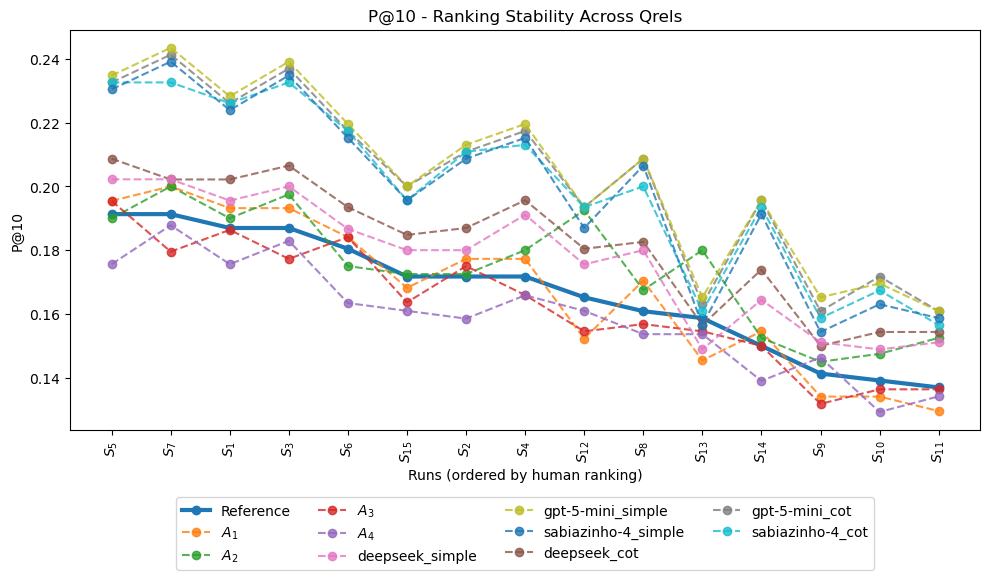

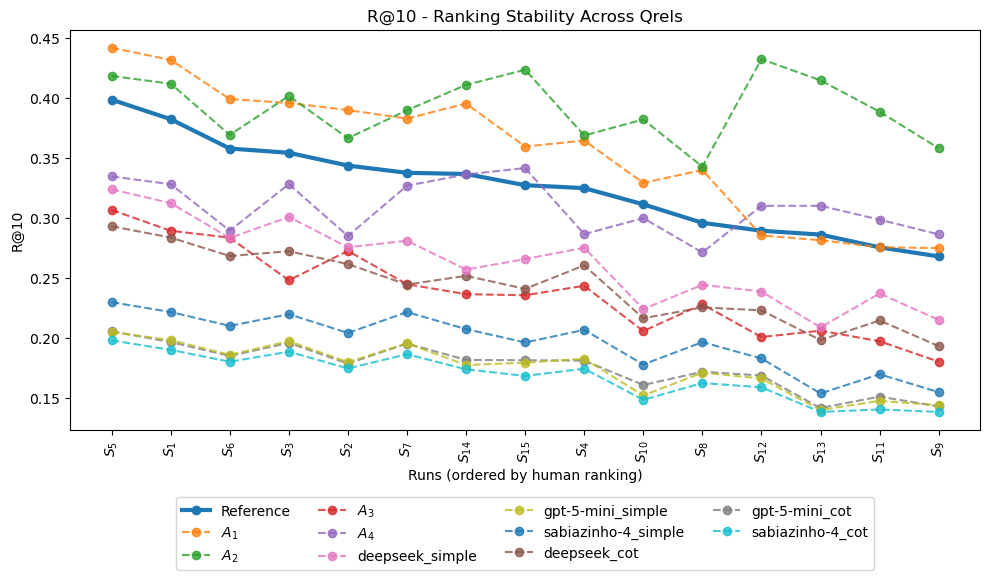

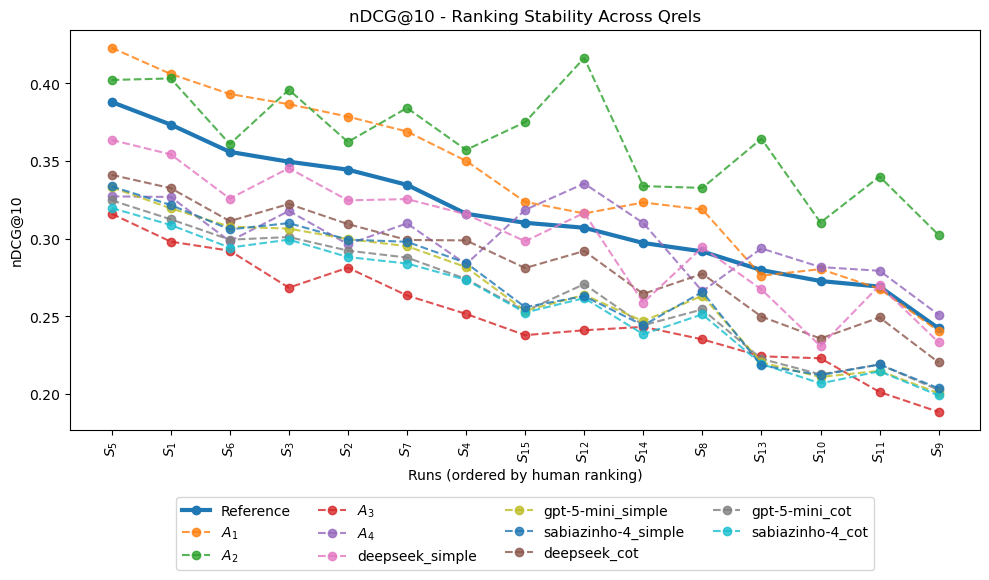

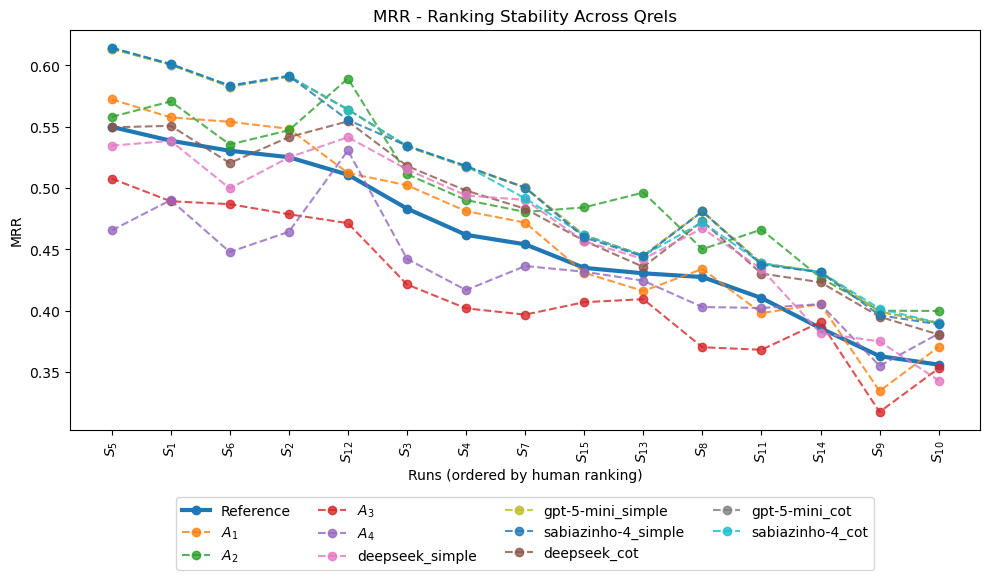

In [13]:
import math
import matplotlib.pyplot as plt

metricas_disponiveis = df_metricas["metric"].unique()

for metrica in metricas_disponiveis:
    df_metrica = df_metricas[df_metricas["metric"] == metrica]
    
    # Pivot para facilitar acesso
    pivot = df_metrica.pivot(
        index="run",
        columns="qrels",
        values="value"
    )
       
    # Ordena runs pelo desempenho humano (decrescente)
    pivot = pivot.sort_values(NOME_QRELS_REF, ascending=False)
    
    runs_ordenados = pivot.index.tolist()
    x = range(len(runs_ordenados))
    
    plt.figure(figsize=(10, 6))
    
    # Dicionário para armazenar linhas (handle da legenda)
    lines_dict = {}
    
    # ===== Plot humano =====
    line_human, = plt.plot(
        x,
        pivot[NOME_QRELS_REF],
        marker="o",
        linewidth=3,
        label=NOME_QRELS_REF
    )
    lines_dict[NOME_QRELS_REF] = line_human
    
    # ===== Plot outros qrels =====
    for qrels_name in pivot.columns:
        if qrels_name == NOME_QRELS_REF:
            continue
        
        line, = plt.plot(
            x,
            pivot[qrels_name],
            marker="o",
            linestyle="--",
            alpha=0.8,
            label=qrels_name
        )
        lines_dict[qrels_name] = line
    
    # =========================
    # 🔹 Ordena legenda segundo subtitle_order
    # =========================
    ordered_handles = [
        lines_dict[name]
        for name in subtitle_order
        if name in lines_dict
    ]
    
    # Configurações do gráfico (plota os runs com subscrito)
    # Converte cada S_XX para $S_{XX}$
    runs_ordenados_com_subscrito = [f"$S_{{{r.split('_')[1]}}}$" if "_" in r else f"${r}$" for r in runs_ordenados]
    plt.xticks(x, runs_ordenados_com_subscrito, rotation=90)
    plt.xlabel("Runs (ordered by human ranking)")
    plt.ylabel(metrica)
    plt.title(f"{metrica} - Ranking Stability Across Qrels")
    
    # 🔹 Legenda abaixo do gráfico
    plt.legend(
        handles=ordered_handles,
        labels=[f"${x}$" if x.startswith("A_") else x for x in subtitle_order],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.15),
        ncol=math.ceil(len(ordered_handles)/3)
    )
    
    plt.tight_layout()
    #plt.savefig(f"ranking_across_qrels_{metrica.replace('@', '_')}.png", dpi=300, bbox_inches="tight")
    plt.show()